# E-commerce Sales Analysis

## Project Overview

This project analyzes e-commerce sales data from Amazon, including both domestic and international transactions.  
The objective is to prepare clean, analysis-ready sales data and explore sales trends, category performance, regional differences, and SKU-level behavior.

The project focuses on descriptive analysis and does not include predictive modeling or cost optimization.

## Dataset Description

The analysis uses transactional sales data from two sources:
- Amazon domestic sales data
- Amazon international sales data

Additional datasets (inventory, expenses, logistics) were reviewed but not incorporated, as they were not required to address the core analytical questions.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [46]:
amazon_ds = pd.read_csv("amazon_sales_clean.csv", parse_dates=['date'])
international_sales_report_ds = pd.read_csv(
    "international_sales_clean.csv",
    parse_dates=['date']
)

In [47]:
amazon_ds['platform'] = 'Amazon'
amazon_ds['region'] = 'Domestic'

international_sales_report_ds['platform'] = 'Amazon'
international_sales_report_ds['region'] = 'International'

In [48]:
sales_df = pd.concat(
    [amazon_ds, international_sales_report_ds],
    ignore_index=True
)

In [49]:
analysis_cols = [
    'date',
    'sku',
    'category',
    'revenue',
    'units_sold',
    'platform',
    'region'
]

sales_analysis_df = sales_df[analysis_cols].copy()

## Data Preparation

Sales data from domestic and international sources were cleaned independently and merged into a unified analysis dataset.  
Only shared transactional fields were retained for analysis to ensure schema consistency

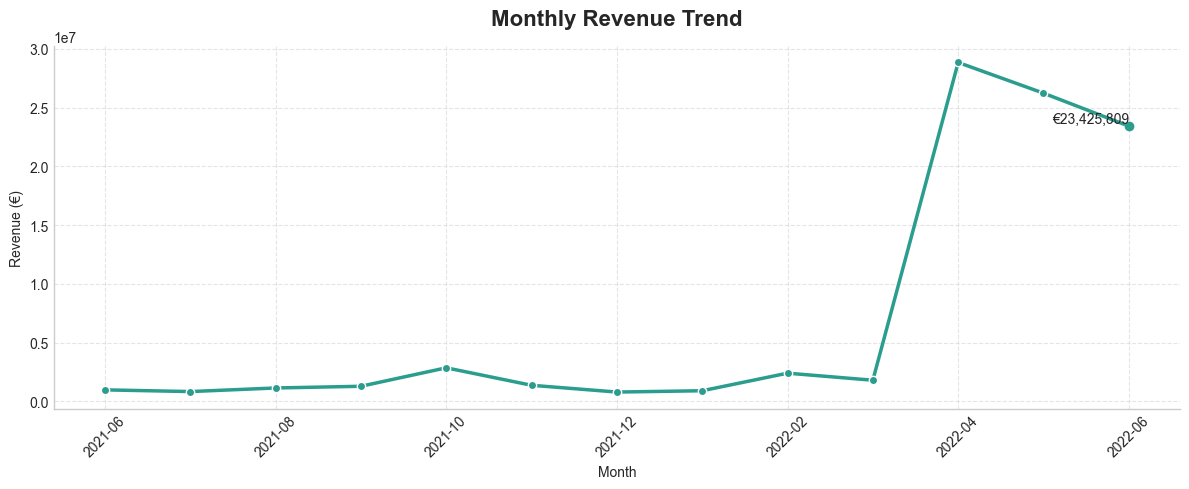

In [50]:

PRIMARY_COLOR = '#2a9d8f'

plt.style.use('seaborn-v0_8-whitegrid')

# Prepare data
sales_analysis_df['month'] = sales_analysis_df['date'].dt.to_period('M')
monthly_revenue = (
    sales_analysis_df
    .groupby('month')['revenue']
    .sum()
)

monthly_revenue.index = monthly_revenue.index.astype(str)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

monthly_revenue.plot(
    ax=ax,
    linewidth=2.5,
    marker='o',
    color=PRIMARY_COLOR,
    markerfacecolor=PRIMARY_COLOR,
    markeredgecolor='white',
    markeredgewidth=1
)

# Title & labels
ax.set_title(
    'Monthly Revenue Trend',
    fontsize=16,
    weight='bold',
    pad=15
)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (€)')

# Ticks
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='both', labelsize=10)

# Clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid
ax.grid(True, linestyle='--', alpha=0.5)

# Highlight last value
last_x = len(monthly_revenue) - 1
last_y = monthly_revenue.iloc[-1]

ax.scatter(last_x, last_y, color=PRIMARY_COLOR, zorder=3)
ax.text(
    last_x,
    last_y,
    f'€{last_y:,.0f}',
    fontsize=10,
    ha='right',
    va='bottom'
)

plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=300)
plt.show()

## Sales Trends Over Time

Monthly aggregation highlights overall revenue trends and reduces daily volatility in sales activity.

In [51]:
category_perf = (
    sales_analysis_df
    .dropna(subset=['category'])
    .groupby('category')
    .agg(
        total_revenue=('revenue', 'sum'),
        total_units=('units_sold', 'sum')
    )
    .sort_values(by='total_revenue', ascending=False)
)

category_perf.head(10)

,total_revenue,total_units
category,,
Set,39204124.03,47042.0
Kurta,21299546.70,46717.0
Western Dress,11216072.69,14704.0
Top,5347792.30,10165.0
Ethnic Dress,791217.66,1093.0
Blouse,458408.18,881.0
Bottom,150667.98,420.0
Saree,123933.76,155.0
Dupatta,915.00,3.0


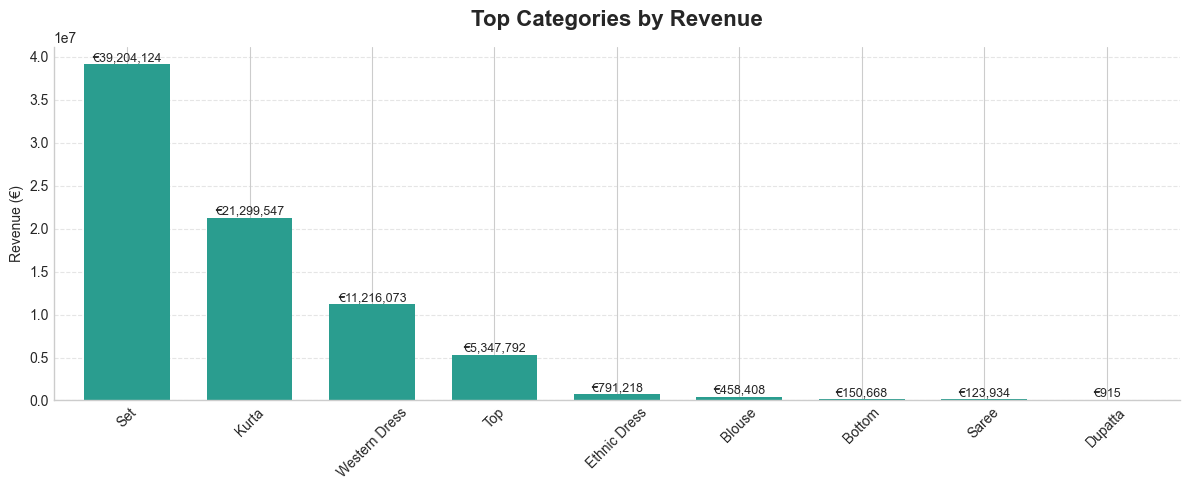

In [52]:

PRIMARY_COLOR = '#2a9d8f'

plt.style.use('seaborn-v0_8-whitegrid')

# Get top 10 categories
top_categories = category_perf.head(10)['total_revenue']

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

top_categories.plot(
    kind='bar',
    ax=ax,
    color=PRIMARY_COLOR,
    width=0.7
)

# Title & labels
ax.set_title(
    'Top Categories by Revenue',
    fontsize=16,
    weight='bold',
    pad=15
)
ax.set_xlabel('')
ax.set_ylabel('Revenue (€)')

# Rotate labels for readability
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='both', labelsize=10)

# Clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Subtle grid
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

# Add value labels (IMPORTANT)
for i, v in enumerate(top_categories):
    ax.text(
        i,
        v,
        f'€{v:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('category_performance.png', dpi=300)
plt.show()

## Category Performance

Product categories were evaluated based on total revenue and units sold.  
Category-level analysis applies to transactions with available classification data.

In [53]:
region_perf = (
    sales_analysis_df
    .groupby('region')
    .agg(
        total_revenue=('revenue', 'sum'),
        total_units=('units_sold', 'sum')
    )
)

region_perf

,total_revenue,total_units
region,,
Domestic,78592678.3,121180.0
International,14349670.0,22394.0


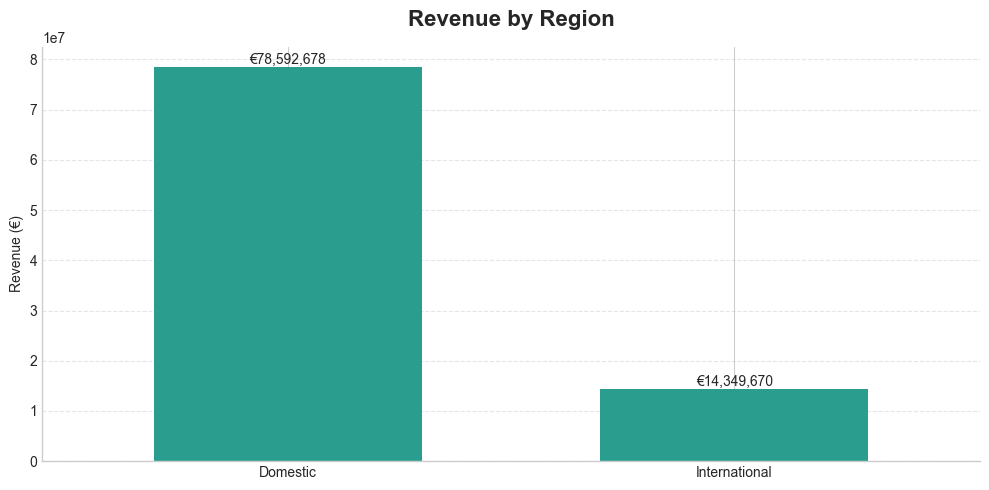

In [54]:


PRIMARY_COLOR = '#2a9d8f'

plt.style.use('seaborn-v0_8-whitegrid')

# Sort for better readability
region_data = region_perf['total_revenue'].sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

region_data.plot(
    kind='bar',
    ax=ax,
    color=PRIMARY_COLOR,
    width=0.6
)

# Title & labels
ax.set_title(
    'Revenue by Region',
    fontsize=16,
    weight='bold',
    pad=15
)
ax.set_xlabel('')
ax.set_ylabel('Revenue (€)')

# Ticks
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='both', labelsize=10)

# Clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid (only Y for clarity)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

# Add value labels
for i, v in enumerate(region_data):
    ax.text(
        i,
        v,
        f'€{v:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.savefig('revenue_by_region.png', dpi=300)
plt.show()

## Domestic vs International Sales

Sales performance was compared between domestic and international transactions to assess differences in revenue contribution and sales volume.

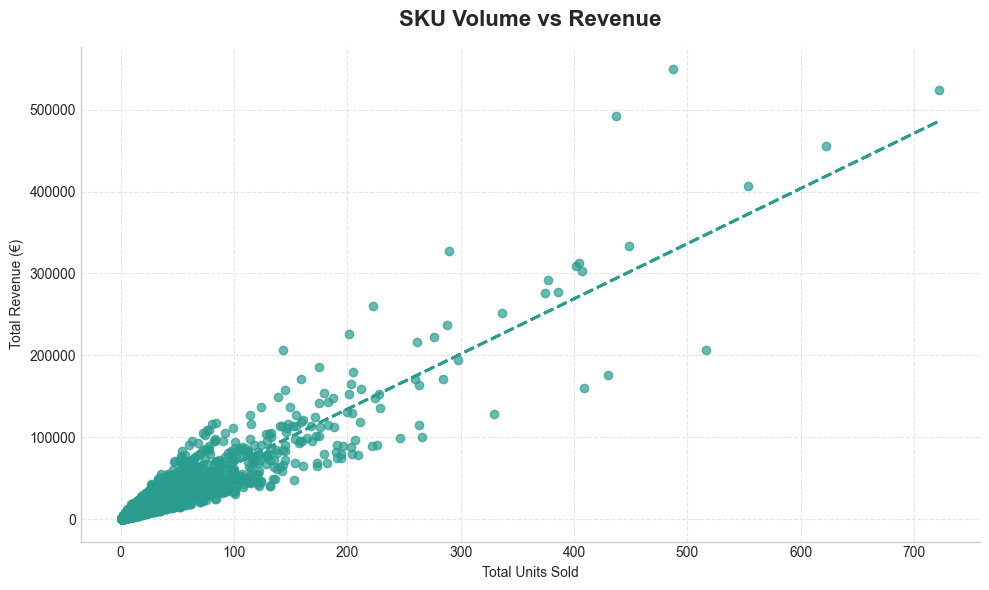

In [55]:
PRIMARY_COLOR = '#2a9d8f'

plt.style.use('seaborn-v0_8-whitegrid')

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    sku_perf['total_units'],
    sku_perf['total_revenue'],
    alpha=0.7,
    color=PRIMARY_COLOR
)

# --- Trend line (IMPORTANT UPGRADE) ---
x = sku_perf['total_units']
y = sku_perf['total_revenue']

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

ax.plot(
    x,
    p(x),
    linestyle='--',
    linewidth=2,
    color=PRIMARY_COLOR
)

# Titles & labels
ax.set_title(
    'SKU Volume vs Revenue',
    fontsize=16,
    weight='bold',
    pad=15
)
ax.set_xlabel('Total Units Sold')
ax.set_ylabel('Total Revenue (€)')

# Clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('sku_volume_vs_revenue.png', dpi=300)
plt.show()

## Volume vs Value Analysis

SKU-level aggregation highlights differences between high-volume products and high-revenue products.  
Products generating the highest sales volume are not always those generating the highest revenue.

## Summary and Conclusions

This project prepared and explored e-commerce sales data from Amazon across domestic and international markets.  
Key findings include identifiable sales trends over time, category-level revenue concentration, regional performance differences, and contrasts between high-volume and high-value products.

The analysis establishes a clean foundation that could be extended with cost, inventory, or logistics data for deeper business insights.